<div style="background-color: #013220; color: white; padding: 10px;">
    <h1>Calculer Perf</h1>
</div>

In [1]:
# %pip install xbbg
# Copier API bloom ds l'env
# %pip install dataframe-image

In [2]:
import pandas as pd
import numpy as np
from xbbg import blp
from datetime import datetime, timedelta
from py_files.PERF_SUIVI import *
%load_ext autoreload
%autoreload 2

screen_path = r"\\groupe-ufg.com\commun\Prive\GestionAM\Ingenierie_Financiere\PROD\_EQUITY\0_SCREEN_AGG\screen_aggregate.pkl"
returns_path = r"\\groupe-ufg.com\commun\Prive\GestionAM\Ingenierie_Financiere\PROD\_EQUITY\0_RETURNS\returns.pkl"

In [3]:
ptf = get_bloom_security_data('.TOP_ML_EU Index', start_date='2015-01-01')
worst_ptf = get_bloom_security_data('.W_ML_EU Index', start_date='2015-01-01')
bench = get_bloom_security_data('M7EU Index', start_date='2015-01-01')

ptf.rename(columns={'.TOP_ML_EU Index' : "TOP ML EU"}, inplace=True)
worst_ptf.rename(columns={'.W_ML_EU Index' : "WORST ML EU"}, inplace=True)
bench.rename(columns={'M7EU Index' : "MSCI EU"}, inplace=True)

# ptf_mf = get_bloom_security_data('.EU_MF_Q1 Index', start_date='2022-01-01')
# ptf_quali = get_bloom_security_data('.EU_QU_Q1 Index', start_date='2022-01-01')
# ptf_growth = get_bloom_security_data('.EU_GR_Q1 Index', start_date='2022-01-01')
# ptf_value = get_bloom_security_data('.EU_VL_Q1 Index', start_date='2022-01-01')
# ptf_mom = get_bloom_security_data('.EU_MM_Q1 Index', start_date='2022-01-01')

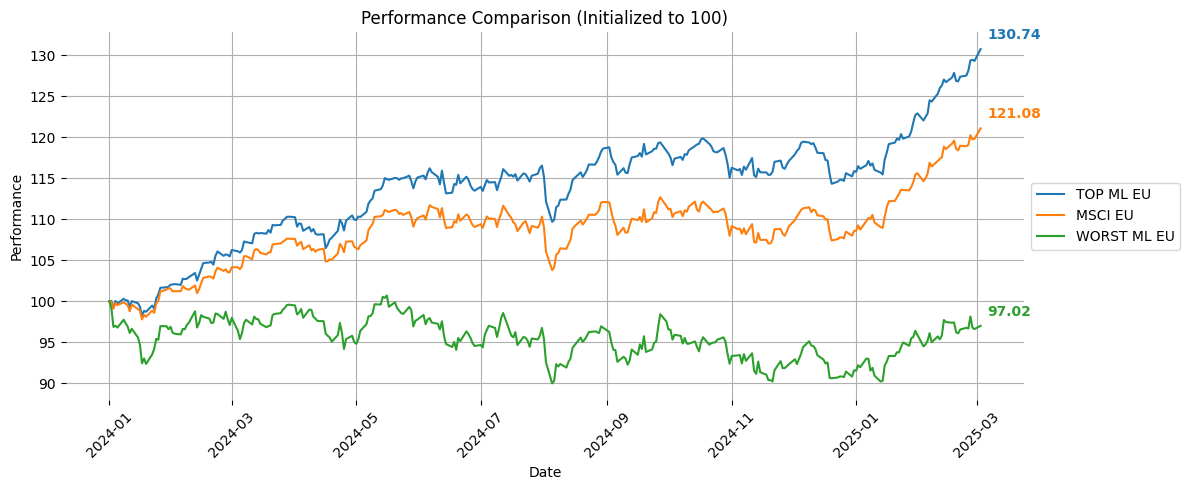

In [4]:
plot_price(ptf, bench, worst_ptf, start_date='2024-01-01', output=r'output_mail\perf_plot.png', figsize=(12, 5))

In [5]:
pd.concat([ptf, worst_ptf, bench], axis=1)

,TOP ML EU,WORST ML EU,MSCI EU
2015-01-01,223.9040,108.8970,176.86
2015-01-02,223.9950,109.0651,176.20
2015-01-05,220.1272,106.3721,172.28
2015-01-06,218.6365,105.6340,171.11
2015-01-07,218.7034,106.0507,171.95
...,...,...,...
2025-02-25,923.6730,121.3178,368.48
2025-02-26,932.5956,123.1459,372.10
2025-02-27,933.1480,121.4321,370.48
2025-02-28,932.1638,121.2238,370.73


In [6]:
perf_results = calculate_multiple_performances(ptf, bench, worst_ptf)
print(perf_results)

# Save ttr pickle for LLM Web App
pd.concat([ptf, worst_ptf, bench], axis=1).to_pickle(r"\\groupe-ufg.com\commun\Prive\GestionAM\Ingenierie_Financiere\PROD\_EQUITY\1_FACTEUR_ML\ML_ptf_webapp\ptf_ttr.pickle")

      TOP ML EU    MSCI EU  WORST ML EU
1w     2.050130   1.677160     0.337131
1m     6.377003   4.726765     1.142568
3m    10.888791  10.168196     4.386438
6m    10.216934   7.999193     0.245742
YTD   12.927871  11.502634     5.987082
1y    20.698217  14.337158    -0.245357
3y    47.624578  32.990203    -0.619664
5y   141.167391  89.289143    24.507679


In [7]:
pd.read_pickle(r"\\groupe-ufg.com\commun\Prive\GestionAM\Ingenierie_Financiere\PROD\_EQUITY\1_FACTEUR_ML\ML_ptf_webapp\ptf_ttr.pickle")

,TOP ML EU,WORST ML EU,MSCI EU
2015-01-01,223.9040,108.8970,176.86
2015-01-02,223.9950,109.0651,176.20
2015-01-05,220.1272,106.3721,172.28
2015-01-06,218.6365,105.6340,171.11
2015-01-07,218.7034,106.0507,171.95
...,...,...,...
2025-02-25,923.6730,121.3178,368.48
2025-02-26,932.5956,123.1459,372.10
2025-02-27,933.1480,121.4321,370.48
2025-02-28,932.1638,121.2238,370.73


<div style="background-color: #013220; color: white; padding: 10px;">
    <h1>Composition Ptf</h1>
    <li>'input_files\ptf_composition.xlsx' should be updated at first with bloomberg plugin in Excel</li>
</div>

In [8]:
current_month = datetime.now().strftime("%B %Y")
base_path = r"\\groupe-ufg.com\commun\Prive\GestionAM\Ingenierie_Financiere\PROD\_EQUITY\0_PTF_BLOOM\PTF"

ptf_top = pd.read_excel(fr"{base_path}\Pour {current_month}\ML ESG EU.xlsx").drop_duplicates()
ptf_worst = pd.read_excel(fr"{base_path}\Pour {current_month}\WORST ML EU.xlsx").drop_duplicates()
# ptf_worst['Weight'] = ptf_worst['Weight']*2
ptf_top['TOP/WORST'] = "TOP"
ptf_worst['TOP/WORST'] = "WORST"
ptf_top = ptf_top.set_index(["ISIN", "Date"])
ptf_worst = ptf_worst.set_index(["ISIN", "Date"])

Updating the basket.pkl for Web App LLM

In [9]:
# This part is for updating the basket.pkl for Web App LLM
screen = pd.read_pickle(screen_path)

screen_last = screen[screen['Date'] == screen['Date'].max()]
screen_last = screen_last.reset_index(names="ISIN")

from dateutil import relativedelta
columns2add = ["Date", "ISIN", "Name", 'Exchange Country Name', 'Symbol', 'Exchange Country Region', ' Benchmark ICB Industry ', 'Benchmark Market Value Millions in EUR', 
            'ESG_ANALYST_SCORE', 'PE LTM', 'EPS Growth FY1', 'ROE avg FY0', 'Oper Margin', 'DVD Yield FY0', 'Earns Yield FY0', 
            'CarbonIntensity_Sales', 
            'Dividend Avg Percentile', 'Value Avg Percentile', 'Quality Avg Percentile', 'Mom Avg Percentile', 'LowVol Avg Percentile', 'Growth Avg Percentile', 
            'Score ML', 'Number Pos. Surprise Earnings (last 8Q)',
                'Number Pos. Surprise Sales (last 8Q)', 'Beta Up vs SXXP (252D)',
                'Beta Down vs SXXP (252D)']
screen2add = screen_last[columns2add]
screen2add['Date'] = pd.to_datetime(screen2add['Date']).apply(lambda x: x + relativedelta.relativedelta(months=1, day=1))
screen2add = screen2add.set_index(["ISIN", "Date"])

screen2add.loc[ptf_top.index, 'Weight'] = ptf_top['Weight']
screen2add.loc[ptf_top.index, 'TOP/WORST'] = ptf_top['TOP/WORST']
screen2add.loc[ptf_worst.index, 'Weight'] = ptf_worst['Weight']
screen2add.loc[ptf_worst.index, 'TOP/WORST'] = ptf_worst['TOP/WORST']

basket = screen2add.dropna(subset='Weight')
basket = basket.reset_index()

basket = basket.rename(columns={'Exchange Country Name' : "Country",
                                # "ICB_INDUSTRY_NAME" : "Sector",
                                ' Benchmark ICB Industry ' : "Sector",
                                "Exchange Country Region" : "Region",
                                "CHG_PCT_5D" : "Perf 1W",
                                "CHG_PCT_1M" : "Perf 1M",
                                "CHG_PCT_3M" : "Perf 3M",
                                "CHG_PCT_1YR" : "Perf 1Y",
                                "Benchmark Market Value Millions in EUR ": "Mkt Cap",
                                'ESG_ANALYST_SCORE' : 'ESG Score',
                                'DVD Yield FY0' : 'DVD Yield',
                                'Earns Yield FY0' : 'Earnings Yield',
                                'ROE avg FY0' : 'ROE',
                                'PE LTM' : 'PE',
                                'CarbonIntensity_Sales' : 'Carbon Intensity',
                                'Dividend Avg Percentile' : 'Div Score', 
                                'Value Avg Percentile' : 'Value Score',
                                'Quality Avg Percentile' : 'Quality Score', 
                                'Mom Avg Percentile' : 'Mom Score', 
                                'Growth Avg Percentile' : 'Growth Score',
                                'LowVol Avg Percentile' : 'LowVol Score'})

from py_files.PERF_SUIVI import create_reverse_sector_dict
# Transform sector code into sector name
reverse_sector_dict = create_reverse_sector_dict()
basket['Sector'] = basket['Sector'].map(reverse_sector_dict)

columns_ordered = ["Date", 'Name', 'Weight', 'Country', 'Sector', 'Symbol', 'Score ML',
            #     'Sector_num', 'Perf 1W', 'Perf 1M', 'Perf 3M', 'Perf 1Y', 'Region', 'ESG Score', 'Carbon Intensity', 'Div Score', 'LowVol Score', 
                'Mkt Cap', 'PE', 'EPS Growth FY1',
                'ROE', 'Oper Margin', 'DVD Yield', 'Earnings Yield',
                'Value Score', 'Quality Score', 'Mom Score', 'Growth Score', 'Div Score', 'LowVol Score', 'Number Pos. Surprise Earnings (last 8Q)',
                'Number Pos. Surprise Sales (last 8Q)', 'Beta Up vs SXXP (252D)',
                'Beta Down vs SXXP (252D)', 'TOP/WORST']
basket = basket[columns_ordered]
basket['Date'] = pd.to_datetime(basket['Date']).dt.strftime('%Y-%m')

from datetime import datetime 
current_date = datetime.now().strftime("%Y%m%d")

basket_histo = pd.read_pickle(r"\\groupe-ufg.com\commun\Prive\GestionAM\Ingenierie_Financiere\PROD\_EQUITY\1_FACTEUR_ML\ML_ptf_webapp\basket.pickle")
basket_histo.to_pickle(fr"\\groupe-ufg.com\commun\Prive\GestionAM\Ingenierie_Financiere\PROD\_EQUITY\1_FACTEUR_ML\ML_ptf_webapp\histo\basket_{current_date}.pickle")
basket = pd.concat([basket_histo, basket], axis=0)
basket = basket.drop_duplicates(subset=['Date', 'Name', 'Symbol'])

basket.to_pickle(r"\\groupe-ufg.com\commun\Prive\GestionAM\Ingenierie_Financiere\PROD\_EQUITY\1_FACTEUR_ML\ML_ptf_webapp\basket.pickle")

C:\Users\LIJN\AppData\Local\Temp\ipykernel_4852\2844691676.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  screen2add['Date'] = pd.to_datetime(screen2add['Date']).apply(lambda x: x + relativedelta.relativedelta(months=1, day=1))


Generating top and worst baskets for MAIL

In [10]:
# This part is for Generating top basket for MAIL
df = pd.read_excel(r'input_files\ptf_composition.xlsx', sheet_name='Feuil1', usecols='A:J', header=0, engine='openpyxl')
basket = df.dropna()[["ID().weights", "ID_ISIN", "ICB_INDUSTRY_NAME", "PX_LAST", "TARGET_PRICE", "ANALYST_UPSIDE_pct", "EPS_BEAT"]]
basket = basket.rename(columns={"ID_ISIN" : "ISIN"})
basket = basket.set_index("ISIN")

screen = pd.read_pickle(screen_path)
# screen = pd.read_pickle(r"C:\Personal Project\DATA\screen_aggregate.pkl")
screen_last = screen[screen['Date'] == screen['Date'].max()]

# print(screen_last.loc['BMG0112X1056', 'EPS Growth FY1'])
# screen_last.loc['BMG0112X1056', 'EPS Growth FY1'] = -6.563
# screen_last.loc['ES0105066007', 'EPS Growth FY1'] = 0

columns2add = ["Name", 'Exchange Country Name', 'Symbol', 'Exchange Country Region', ' Benchmark ICB Industry ', 'Benchmark Market Value Millions in EUR', 
               'ESG_ANALYST_SCORE', 'PE LTM', 'EPS Growth FY1', 'ROE avg FY0', 'Oper Margin', 'DVD Yield FY0', 'Earns Yield FY0', 
               'CarbonIntensity_Sales', 
               'Dividend Avg Percentile', 'Value Avg Percentile', 'Quality Avg Percentile', 'Mom Avg Percentile', 'LowVol Avg Percentile', 'Growth Avg Percentile', 
               'Score ML']
screen2add = screen_last[columns2add]

basket = basket.merge(screen2add, how='left', left_index=True, right_index=True)

basket = basket.rename(columns={"ID().weights" : "Weight",
                                'Exchange Country Name' : "Country",
                                "ICB_INDUSTRY_NAME" : "Sector",
                                ' Benchmark ICB Industry ' : "Sector_num",
                                "Exchange Country Region" : "Region",
                                "CHG_PCT_5D" : "Perf 1W",
                                "CHG_PCT_1M" : "Perf 1M",
                                "CHG_PCT_3M" : "Perf 3M",
                                "CHG_PCT_1YR" : "Perf 1Y",
                                "Benchmark Market Value Millions in EUR ": "Mkt Cap",
                                'ESG_ANALYST_SCORE' : 'ESG Score',
                                'DVD Yield FY0' : 'DVD Yield',
                                'Earns Yield FY0' : 'Earnings Yield',
                                'ROE avg FY0' : 'ROE',
                                'PE LTM' : 'PE',
                                'CarbonIntensity_Sales' : 'Carbon Intensity',
                                'Dividend Avg Percentile' : 'Div Score', 
                                'Value Avg Percentile' : 'Value Score',
                                'Quality Avg Percentile' : 'Quality Score', 
                                'Mom Avg Percentile' : 'Mom Score', 
                                'Growth Avg Percentile' : 'Growth Score',
                                'LowVol Avg Percentile' : 'LowVol Score',
                                # 'PX_UPSIDE_pct' : 'Px Upside pct',
                                'EPS_BEAT' : 'Eps Beat for Last 8Y'})

columns_ordered = ['Name', 'Weight', 'Country', 'Sector', 'Symbol', 'Score ML',
               #     'Sector_num', 'Perf 1W', 'Perf 1M', 'Perf 3M', 'Perf 1Y', 'Region', 'ESG Score', 'Carbon Intensity', 'Div Score', 'LowVol Score', 
                   'Mkt Cap', 'PE', 'EPS Growth FY1',
                   'ROE', 'Oper Margin', 'DVD Yield', 'Earnings Yield',
                   'Value Score', 'Quality Score', 'Mom Score', 'Growth Score', 'Div Score', 'LowVol Score', 
                   'Eps Beat for Last 8Y', "PX_LAST", "TARGET_PRICE", "ANALYST_UPSIDE_pct"]
basket = basket[columns_ordered]
basket.to_excel(r'output_mail\basket.xlsx')

In [11]:
# df_cleaned = basket[basket['Eps Beat for Last 8Y'] != '#N/A N/A: Error occurred during request processing./10']
# df_cleaned.to_excel(r'output_mail\basket.xlsx')

In [12]:
# This part is for Generating worst basket for MAIL
df = pd.read_excel(r'input_files\ptf_composition_worst.xlsx', sheet_name='Feuil1', usecols='A:J', header=0, engine='openpyxl')
basket_worst = df.dropna()[["ID().weights", "ID_ISIN", "ICB_INDUSTRY_NAME", "PX_LAST", "TARGET_PRICE", "ANALYST_UPSIDE_pct", "EPS_BEAT"]]
basket_worst = basket_worst.rename(columns={"ID_ISIN" : "ISIN"})
basket_worst = basket_worst.set_index("ISIN")

screen = pd.read_pickle(screen_path)
# screen = pd.read_pickle(r"C:\Personal Project\DATA\screen_aggregate.pkl")
screen_last = screen[screen['Date'] == screen['Date'].max()]

columns2add = ["Name", 'Exchange Country Name', 'Symbol', 'Exchange Country Region', ' Benchmark ICB Industry ', 'Benchmark Market Value Millions in EUR', 
               'ESG_ANALYST_SCORE', 'PE LTM', 'EPS Growth FY1', 'ROE avg FY0', 'Oper Margin', 'DVD Yield FY0', 'Earns Yield FY0', 
               'CarbonIntensity_Sales', 
               'Dividend Avg Percentile', 'Value Avg Percentile', 'Quality Avg Percentile', 'Mom Avg Percentile', 'LowVol Avg Percentile', 'Growth Avg Percentile', 
               'Score ML']
screen2add = screen_last[columns2add]

basket_worst = basket_worst.merge(screen2add, how='left', left_index=True, right_index=True)

basket_worst = basket_worst.rename(columns={"ID().weights" : "Weight",
                                'Exchange Country Name' : "Country",
                                "ICB_INDUSTRY_NAME" : "Sector",
                                ' Benchmark ICB Industry ' : "Sector_num",
                                "Exchange Country Region" : "Region",
                                "CHG_PCT_5D" : "Perf 1W",
                                "CHG_PCT_1M" : "Perf 1M",
                                "CHG_PCT_3M" : "Perf 3M",
                                "CHG_PCT_1YR" : "Perf 1Y",
                                "Benchmark Market Value Millions in EUR ": "Mkt Cap",
                                'ESG_ANALYST_SCORE' : 'ESG Score',
                                'DVD Yield FY0' : 'DVD Yield',
                                'Earns Yield FY0' : 'Earnings Yield',
                                'ROE avg FY0' : 'ROE',
                                'PE LTM' : 'PE',
                                'CarbonIntensity_Sales' : 'Carbon Intensity',
                                'Dividend Avg Percentile' : 'Div Score', 
                                'Value Avg Percentile' : 'Value Score',
                                'Quality Avg Percentile' : 'Quality Score', 
                                'Mom Avg Percentile' : 'Mom Score', 
                                'Growth Avg Percentile' : 'Growth Score',
                                'LowVol Avg Percentile' : 'LowVol Score',
                                # 'PX_UPSIDE_pct' : 'Px Upside pct',
                                'EPS_BEAT' : 'Eps Beat for Last 8Y'})

columns_ordered = ['Name', 'Weight', 'Country', 'Sector', 'Symbol', 'Score ML',
               #     'Sector_num', 'Perf 1W', 'Perf 1M', 'Perf 3M', 'Perf 1Y', 'Region', 'ESG Score', 'Carbon Intensity', 'Div Score', 'LowVol Score', 
                   'Mkt Cap', 'PE', 'EPS Growth FY1',
                   'ROE', 'Oper Margin', 'DVD Yield', 'Earnings Yield',
                   'Value Score', 'Quality Score', 'Mom Score', 'Growth Score', 'Div Score', 'LowVol Score', 
                   'Eps Beat for Last 8Y', "PX_LAST", "TARGET_PRICE", "ANALYST_UPSIDE_pct"]
basket_worst = basket_worst[columns_ordered]

<div style="background-color: #013220; color: white; padding: 10px;">
    <h1>Composition Bench</h1>
</div>

In [13]:
bench_list = screen_last.dropna(subset='Weight in STOXX EUROPE 600')

In [14]:
bench_list = screen_last.dropna(subset='Weight in STOXX EUROPE 600')
bench_list = bench_list.rename(columns={  "Exchange Country Name" : "Country",
                                'Weight in STOXX EUROPE 600' : 'Weight',
                                ' Benchmark ICB Industry ' : "Sector",
                                "Exchange Country Region" : "Region",
                                "Benchmark Market Value Millions in EUR ": "Mkt Cap",
                                'ESG_ANALYST_SCORE' : 'ESG Score',
                                'DVD Yield FY0' : 'DVD Yield',
                                'Earns Yield FY0' : 'Earnings Yield',
                                'ROE avg FY0' : 'ROE',
                                'PE LTM' : 'PE',
                                'CarbonIntensity_Sales' : 'Carbon Intensity',
                                'Dividend Avg Percentile' : 'Div Score', 
                                'Value Avg Percentile' : 'Value Score',
                                'Quality Avg Percentile' : 'Quality Score', 
                                'Mom Avg Percentile' : 'Mom Score', 
                                'Growth Avg Percentile' : 'Growth Score',
                                'LowVol Avg Percentile' : 'LowVol Score'})
columns_ordered_bench = ['Name', 'Weight', 'Country', 'Region', 'Sector', 'Symbol', 'Mkt Cap', 'Score ML',
                        #  'ESG Score', 'Carbon Intensity', 'Div Score', 
                         'PE', 'EPS Growth FY1', 'LowVol Score', 
                        'ROE', 'Oper Margin', 'DVD Yield', 'Earnings Yield',
                        'Value Score', 'Quality Score',
                        'Mom Score', 'Growth Score']
bench_list = bench_list[columns_ordered_bench]

In [15]:
# Transform sector code into sector name
reverse_sector_dict = create_reverse_sector_dict()
bench_list['Sector'] = bench_list['Sector'].map(reverse_sector_dict)

<div style="background-color: #013220; color: white; padding: 10px;">
    <h1>Top and Worst Baskets' Metrics</h1>
</div>

Top bakset

In [16]:
metrics = calculate_portfolio_metrics(ptf, bench)

print(f"Tracking Error: {metrics['tracking_error']:.4f}")
print(f"Beta: {metrics['beta']:.4f}")
print(f"R-squared: {metrics['r_squared']:.4f}")

Tracking Error: 0.0316
Beta: 0.9666
R-squared: 0.9618


In [17]:
columns_to_sum = ['PE', 'ROE', 'Oper Margin', 
                  'Earnings Yield', 'Value Score', 'Quality Score', 'Mom Score', 
                  'Growth Score', 'Score ML']

ratio_basket_bench = calculate_weighted_sums(basket, bench_list, columns_to_sum=columns_to_sum)
ratio_basket_bench.index = ['Top', 'Bench']
ratio_basket_bench = ratio_basket_bench.T


result_df_2 = ratio_basket_bench.copy(deep=True)
result_df_2.loc['TE', "Top"] = metrics['tracking_error']
result_df_2.loc['Beta', "Top"] = metrics['beta']
result_df_2.loc['R_squared', "Top"] = metrics['r_squared']

result_df_2.loc['Nb Titres', "Top"] = len(basket)
result_df_2.loc['Nb Titres', "Bench"] = len(bench_list)

result_df_2 = result_df_2.round(2)

# FORCAGE BENCH
result_df_2.loc['TE', "Bench"] = 0
result_df_2.loc['Beta', "Bench"] = 1
result_df_2.loc['R_squared', "Bench"]=1

ratio_top = result_df_2.copy(deep=True)

In [18]:
ratio_top

,Top,Bench
PE,17.99,60.24
ROE,16.83,18.43
Oper Margin,28.72,19.23
Earnings Yield,8.52,5.87
Value Score,6.13,4.50
Quality Score,5.35,5.28
Mom Score,6.71,5.64
Growth Score,5.93,5.69
Score ML,9.21,5.19
TE,0.03,0.00


Worst basket

In [19]:
metrics = calculate_portfolio_metrics(worst_ptf, bench)

print(f"Tracking Error: {metrics['tracking_error']:.4f}")
print(f"Beta: {metrics['beta']:.4f}")
print(f"R-squared: {metrics['r_squared']:.4f}")

columns_to_sum = ['PE', 'ROE', 'Oper Margin', 
                  'Earnings Yield', 'Value Score', 'Quality Score', 'Mom Score', 
                  'Growth Score', 'Score ML']

ratio_basket_bench = calculate_weighted_sums(basket_worst, bench_list, columns_to_sum=columns_to_sum)
ratio_basket_bench.index = ['Worst', 'Bench']
ratio_basket_bench = ratio_basket_bench.T


result_df_2 = ratio_basket_bench.copy(deep=True)
result_df_2.loc['TE', "Worst"] = metrics['tracking_error']
result_df_2.loc['Beta', "Worst"] = metrics['beta']
result_df_2.loc['R_squared', "Worst"] = metrics['r_squared']

result_df_2.loc['Nb Titres', "Worst"] = len(basket_worst)
result_df_2.loc['Nb Titres', "Bench"] = len(bench_list)

result_df_2 = result_df_2.round(2)

# FORCAGE BENCH
result_df_2.loc['TE', "Bench"] = 0
result_df_2.loc['Beta', "Bench"] = 1
result_df_2.loc['R_squared', "Bench"]=1

ratio_worst = result_df_2.copy(deep=True)

Tracking Error: 0.0801
Beta: 1.1279
R-squared: 0.8449


In [20]:
ratio_worst

,Worst,Bench
PE,38.54,60.24
ROE,6.31,18.43
Oper Margin,-1.39,19.23
Earnings Yield,1.30,5.87
Value Score,3.55,4.50
Quality Score,3.60,5.28
Mom Score,3.14,5.64
Growth Score,4.41,5.69
Score ML,0.86,5.19
TE,0.08,0.00


In [21]:
ratio_df = ratio_top.copy(deep=True)
ratio_df['Worst'] = ratio_worst['Worst']

In [22]:
ratio_df  

,Top,Bench,Worst
PE,17.99,60.24,38.54
ROE,16.83,18.43,6.31
Oper Margin,28.72,19.23,-1.39
Earnings Yield,8.52,5.87,1.30
Value Score,6.13,4.50,3.55
Quality Score,5.35,5.28,3.60
Mom Score,6.71,5.64,3.14
Growth Score,5.93,5.69,4.41
Score ML,9.21,5.19,0.86
TE,0.03,0.00,0.08


<div style="background-color: #013220; color: white; padding: 10px;">
    <h1>Best Returns and Worst Returns Firms</h1>
</div>

In [23]:
returns = pd.read_pickle(returns_path)

In [24]:
import pandas as pd
import numpy as np

end_date = pd.Timestamp.today().strftime('%Y-%m-%d')
periodic_returns = calculate_periodic_returns(returns, columns=basket['Symbol'].unique().tolist(), start_date='2023-01-01', end_date=end_date)
periodic_returns

,1 Week Return,1 Month Return,3 Month Return,6 Month Return,1 Year Return
JYXN9V-R,1.823284,-4.347837,1.873580,5.976217,30.941335
RFRHDN-R,-0.200955,-0.475366,-9.364348,-19.765464,-8.772346
GSX767-R,3.198985,10.631025,26.994511,16.100019,33.921579
T1Q642-R,3.857573,6.663965,23.024963,32.173565,42.828325
VJ7HTK-R,0.088395,-1.192541,5.048319,11.496509,27.518362
...,...,...,...,...,...
DTHPQT-R,-4.615639,-4.621259,4.607022,7.958944,48.678133
JH4B5Q-R,-3.397613,0.063355,0.200068,1.501440,4.380216
KNHDSG-R,5.546404,1.505152,6.150657,19.550544,77.572505
BCFSNZ-R,0.894862,-2.790574,-0.496237,-1.118950,24.412052


In [25]:
results_rtd_screen = periodic_returns.merge(basket[['Symbol', 'Name', 'Sector', 'Weight']], left_index=True, right_on='Symbol')
top_25_weekly = results_rtd_screen.sort_values('1 Week Return', ascending=False)[['Name', 'Sector', 'Weight', '1 Week Return']].head(25)
top_25_weekly['Weight'] = top_25_weekly['Weight'] * 100
top_25_weekly = top_25_weekly.round(2)
worst_25_weekly = results_rtd_screen.sort_values('1 Week Return', ascending=True)[['Name', 'Sector', 'Weight', '1 Week Return']].head(25)
worst_25_weekly['Weight'] = worst_25_weekly['Weight'] * 100
worst_25_weekly = worst_25_weekly.round(2)

<div style="background-color: #013220; color: white; padding: 10px;">
    <h1> Secto : Basket vs Bench - Weight</h1>
</div>

In [26]:
basket_secto_weight = basket.reset_index().groupby('Sector').agg({'ISIN': 'count', 'Weight': 'sum'}).rename(columns={'ISIN': 'Nb titres',
                                                                                                                    'Weight': 'Weight Ptf'})
bench_secto_wieght = bench_list.groupby('Sector').agg({'Weight': 'sum'}).rename(columns={'Weight': 'Weight Bench'})

In [27]:
secto_weight = pd.concat([basket_secto_weight, bench_secto_wieght], axis=1)
secto_weight['Pct +/-'] = (secto_weight['Weight Ptf'] - secto_weight['Weight Bench']) * 100

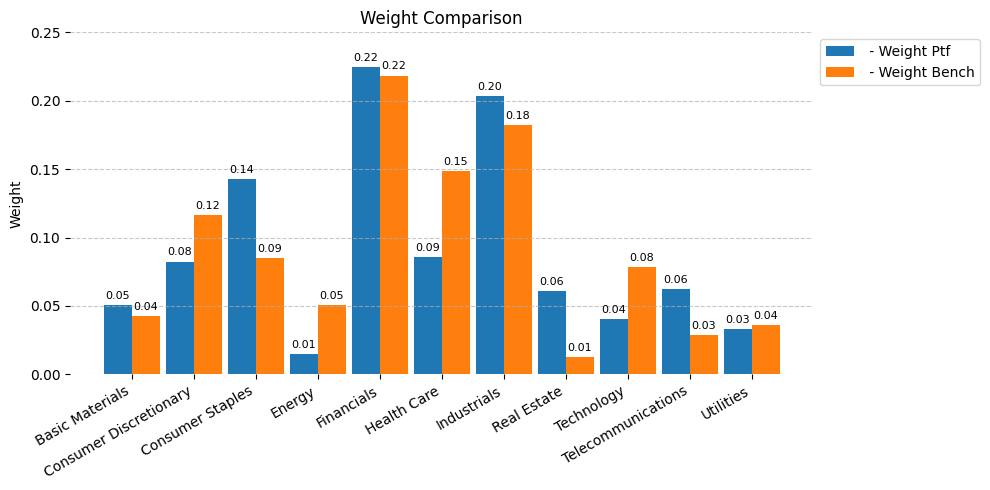

In [28]:
create_bar_plot(secto_weight[['Weight Ptf', 'Weight Bench']], 
                ylabel='Weight', 
                title='Weight Comparison', 
                save_path='output_mail/weight_comparison_secto.png', 
                labels=[''],
                figsize=(10, 5),
                ylim=(0, 0.25),
                rotation=30)

<div style="background-color: #013220; color: white; padding: 10px;">
    <h1> Secto : Basket vs Bench - Returns</h1>
</div>

In [29]:
# Usage for portfolio
returns_sector_portfolio = calculate_sector_returns(
    returns, 
    basket, 
    start_date='2023-01-01', 
    end_date='2025-01-02',
    periods=['1 Week', '1 Month', '3 Month', '6 Month', '1 Year']
)

# Usage for benchmark
returns_sector_benchmark = calculate_sector_returns(
    returns, 
    bench_list, 
    start_date='2023-01-01', 
    end_date='2025-01-02',
    periods=['1 Week', '1 Month', '3 Month', '6 Month', '1 Year']
)

returns_sector_benchmark = returns_sector_benchmark.add_suffix(' Bench')
combined_returns = pd.concat([returns_sector_portfolio, returns_sector_benchmark], axis=1)

combined_returns['+/-'] = combined_returns['1 Week Rdt Weighted'] - combined_returns['1 Week Rdt Weighted Bench']

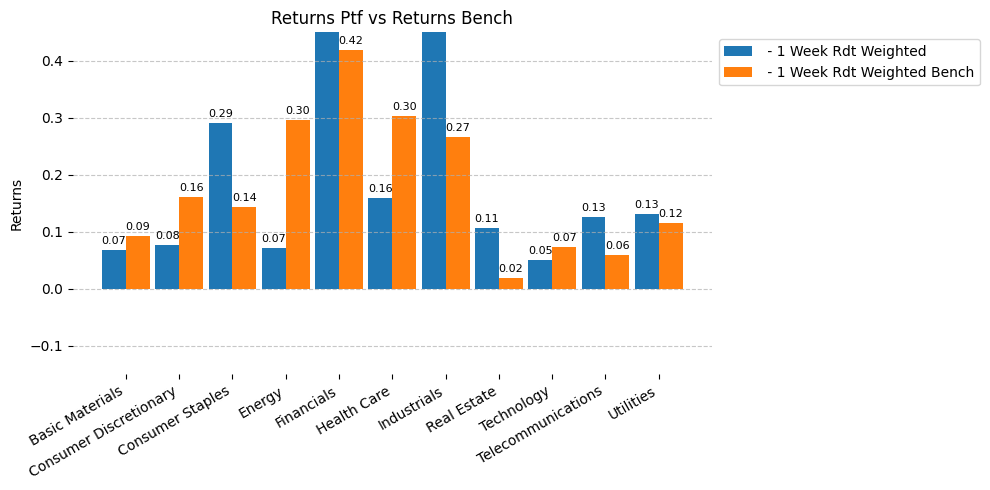

In [30]:
create_bar_plot(combined_returns[['1 Week Rdt Weighted', '1 Week Rdt Weighted Bench']], 
                ylabel='Returns', 
                title='Returns Ptf vs Returns Bench', 
                save_path=r'output_mail\rdt_comparaison_secto.png', 
                labels=[''],
                figsize=(10, 5),
                ylim=(-0.15, 0.45),
                rotation=30)

<div style="background-color: #013220; color: white; padding: 10px;">
    <h1>Save to Image</h1>
</div>

In [31]:
save_dataframe_as_image(perf_results.T, r'output_mail\periodic_perf.png')
save_dataframe_as_image(ratio_df, r'output_mail\metrics.png')

basket_plot = basket.rename(columns={'Weight':'Weight %'})
# basket_plot = df_cleaned.rename(columns={'Weight':'Weight %'})
basket_plot['Weight %'] = basket_plot['Weight %'] * 100
basket_plot = basket_plot.sort_values(by='Weight %', ascending=False)
save_dataframe_as_image(basket_plot, r'output_mail\basket_top.png')

# save_dataframe_as_image(secto_weight, r'output_mail\weights_secto.png')

save_dataframe_as_image(top_25_weekly, r'output_mail\top_25_weekly.png', col_width=20)
save_dataframe_as_image(worst_25_weekly, r'output_mail\worst_25_weekly.png', col_width=20)



\\groupe-ufg.com\commun\Prive\GestionAM\Ingenierie_Financiere\PROD\_EQUITY\1_FACTEUR_ML\py_files\PERF_SUIVI.py:187: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_formatted = df.applymap(format_value)
\\groupe-ufg.com\commun\Prive\GestionAM\Ingenierie_Financiere\PROD\_EQUITY\1_FACTEUR_ML\py_files\PERF_SUIVI.py:195: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  styled_df = df_formatted.style.applymap(style_nan)


DataFrame saved as output_mail\periodic_perf.png
DataFrame saved as output_mail\metrics.png
DataFrame saved as output_mail\basket_top.png
DataFrame saved as output_mail\top_25_weekly.png
DataFrame saved as output_mail\worst_25_weekly.png


<div style="background-color: #013220; color: white; padding: 10px;">
    <h1>Generate Mail</h1>
</div>

In [32]:
import win32com.client as win32
import os
import sys

def generate_and_send_mail(subject, recipients, body, attachments=None, embedded_images=None, tables=None, auto_send=False):
    """
    Generate and send an email using Outlook.

    Parameters:
    -----------
    subject : str
        The subject of the email.
    recipients : str or list
        Email address(es) of the recipient(s). Can be a string for a single recipient or a list for multiple.
    body : str
        The main body of the email in HTML format.
    attachments : list of str, optional
        List of file paths to be attached to the email.
    embedded_images : dict, optional
        Dictionary of image IDs and their file paths to be embedded in the email body.
    tables : list of pandas.DataFrame or list of str, optional
        List of pandas DataFrames or HTML strings to be included in the email body.
    auto_send : bool, optional
        If True, sends the email automatically. If False, displays the email draft. Default is False.

    Returns:
    --------
    None
    """
    try:
        outlook = win32.Dispatch('outlook.application')
        mail = outlook.CreateItem(0)

        # Set recipients
        if isinstance(recipients, list):
            mail.To = '; '.join(recipients)
        else:
            mail.To = recipients

        mail.Subject = subject

        # Attach files
        if attachments:
            for file_path in attachments:
                if os.path.exists(file_path):
                    try:
                        mail.Attachments.Add(file_path)
                    except Exception as e:
                        print(f"Error attaching file {file_path}: {str(e)}")
                else:
                    print(f"Warning: Attachment not found - {file_path}")

        # Embed images
        if embedded_images:
            for img_id, img_path in embedded_images.items():
                if os.path.exists(img_path):
                    try:
                        attachment = mail.Attachments.Add(img_path)
                        attachment.PropertyAccessor.SetProperty("http://schemas.microsoft.com/mapi/proptag/0x3712001F", img_id)
                    except Exception as e:
                        print(f"Error embedding image {img_path}: {str(e)}")
                else:
                    print(f"Warning: Embedded image not found - {img_path}")

        # Process tables
        html_tables = []
        if tables:
            for i, table in enumerate(tables):
                if hasattr(table, 'to_html'):  # If it's a pandas DataFrame
                    html_table = table.to_html(index=True, border=0)
                    html_table = html_table.replace(
                        '<table', f'<table style="width:100%; text-align: center; border-collapse: collapse;" id="table{i}"'
                    )
                    html_table = html_table.replace('<th', '<th style="border: 1px solid black; padding: 5px;"')
                    html_table = html_table.replace('<td', '<td style="border: 1px solid black; padding: 5px;"')
                else:  # If it's already an HTML string
                    html_table = table
                html_tables.append(html_table)

        # Combine body and tables
        full_body = body
        for i, html_table in enumerate(html_tables):
            full_body += f"<br><br>{html_table}"

        mail.HTMLBody = full_body

        if auto_send:
            mail.Send()
        else:
            mail.Display(True)

    except Exception as e:
        print(f"An error occurred: {str(e)}")
        print(f"Error type: {type(e).__name__}")
        print(f"Error details: {sys.exc_info()}")

import datetime
current_month = datetime.datetime.now().strftime("%B")

# Example usage
subject = "ESG ML Portfolio Weekly Performance Analysis"
recipients = ["recipient1@example.com", "recipient2@example.com"]
body = f"""
<p>Bonjour à tous,</p>
<p>   </p>
<p>Suivi de notre portefeuille Machine Learning Action Europe pour implémentation sur le mois {current_month} 2024.</p>
<p>Univers investissable : Stoxx600</p>
<p>   </p>
<p>   </p>
<p>   </p>
<h3 style="text-decoration: underline;">Methodology</h3>
<p>We score companies on different investment styles like Growth (5y past growth on Sales and EPS & FY1 Growth Income, EPS, Sales), Valuation (PE, PB, Price to CF, EV/Ebitda, EV/Sales : L12M and FY1), Balance Sheet Quality (ROE, ROTE, Operating Margin, Leverage, Earnings variability).</p>
<p>We used these scores and their dynamics (3M, 6M and 12M : this allows us to capture not just static financial positions but also the trajectory) as inputs in our machine learning models to find companies with high potential.</p>
<p>We use XGBoost, an advanced algorithm, to find relationship between past financial data and performances the month after.</p>
<p>You can find attached the Methodology</p>
<p>   </p>
<p>   </p>
<p>   </p>
<h3 style="text-decoration: underline;">Current Position of the TOP Portfolio Europe for {current_month} 2024 :</h3>
<p>Here are the full list of Top basket, Excel version is also attached for your reference.</p>
<p>Key Metrics in the column and Best Analyst Target Price and %Analyst Upside Price</p>
<img src="cid:basket_top" style="width:70%; max-width:800px;">
<p>   </p>
<p>   </p>
<p>   </p>
<h3 style="text-decoration: underline;">Periodic Performance (%)</h3>
<img src="cid:periodic_perf" style="width:70%; max-width:800px;"><br>
<img src="cid:perf_plot" style="width:70%; max_width:800px;">
<p>Portfolio TOP and WORST are tickerized in Bloomberg, we can open the access on request to follow membership and performances.</p>
<p>   </p>
<h3 style="text-decoration: underline;">Metrics</h3>
<img src="cid:metrics" style="width:70%; max-width:800px;">
<p>   </p>
<h3 style="text-decoration: underline;">Top 25 and Worst 25 Performing Companies of Top</h3>
<img src="cid:top_25_weekly" style="width:70%; max-width:800px;">
<img src="cid:worst_25_weekly" style="width:70%; max-width:800px;">
<p>   </p>
<h3 style="text-decoration: underline;">Comparison per Sector</h3>
<img src="cid:weight_comparison_secto" style="width:70%; max-width:800px;"><p>   </p>
<img src="cid:rdt_comparison_secto" style="width:70%; max-width:800px;">
<p>   </p>
<p>Best regards,</p>
"""

attachments = [r'\\groupe-ufg.com\commun\Prive\GestionAM\Ingenierie_Financiere\PROD\_EQUITY\1_FACTEUR_ML\output_mail\basket.xlsx']
embedded_images = {
    "perf_plot": r"\\groupe-ufg.com\commun\Prive\GestionAM\Ingenierie_Financiere\PROD\_EQUITY\1_FACTEUR_ML\output_mail\perf_plot.png",
    "periodic_perf": r"\\groupe-ufg.com\commun\Prive\GestionAM\Ingenierie_Financiere\PROD\_EQUITY\1_FACTEUR_ML\output_mail\periodic_perf.png",
    "metrics": r"\\groupe-ufg.com\commun\Prive\GestionAM\Ingenierie_Financiere\PROD\_EQUITY\1_FACTEUR_ML\output_mail\metrics.png",
    "top_25_weekly": r"\\groupe-ufg.com\commun\Prive\GestionAM\Ingenierie_Financiere\PROD\_EQUITY\1_FACTEUR_ML\output_mail\top_25_weekly.png",
    "worst_25_weekly": r"\\groupe-ufg.com\commun\Prive\GestionAM\Ingenierie_Financiere\PROD\_EQUITY\1_FACTEUR_ML\output_mail\worst_25_weekly.png",
    "weight_comparison_secto": r"\\groupe-ufg.com\commun\Prive\GestionAM\Ingenierie_Financiere\PROD\_EQUITY\1_FACTEUR_ML\output_mail\weight_comparison_secto.png",
    "rdt_comparison_secto": r"\\groupe-ufg.com\commun\Prive\GestionAM\Ingenierie_Financiere\PROD\_EQUITY\1_FACTEUR_ML\output_mail\rdt_comparaison_secto.png",
    "basket_top": r"\\groupe-ufg.com\commun\Prive\GestionAM\Ingenierie_Financiere\PROD\_EQUITY\1_FACTEUR_ML\output_mail\basket_top.png"
}

generate_and_send_mail(subject, recipients, body, attachments, embedded_images)